In [ ]:
import os
if 'PATH_SET' not in locals():
    os.chdir('../..')
    PATH_SET = True
    
import torch    

if 'THREADS_SET' not in locals():
    try:
        os.environ['OMP_NUM_THREADS'] = '1'
        os.environ['MKL_NUM_THREADS'] = '1'
        
        torch.set_num_threads(1)
        torch.set_num_interop_threads(1)
        THREADS_SET = True
    except:
        pass

import numpy as np

import xarray as xr

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle_background.mplstyle')

figure_path = 'figures/priors/data_prior/'
os.makedirs(figure_path, exist_ok=True)

In [ ]:
from helpers.geographic_setup import (
    design_space_full, design_space_shoulder,
    events_shoulder,
    topo_data
)

In [ ]:
vp_model_shoulder = xr.load_dataarray(
    'data/velocity_model/3d_model_final/vp_xarray.nc',
    engine='netcdf4',
    format='NETCDF4'
    )

In [ ]:
topo_spacing = 10

topo_data_interp = topo_data.interp(
    easting=np.arange(vp_model_shoulder.easting.min(), vp_model_shoulder.easting.max(), topo_spacing),
    northing=np.arange(vp_model_shoulder.northing.min(), vp_model_shoulder.northing.max(), topo_spacing)
)

x_min, x_max, x_N = (
    topo_data_interp.easting.values.min(),
    topo_data_interp.easting.values.max(),
    topo_data_interp.easting.size)

y_min, y_max, y_N = (
    topo_data_interp.northing.values.min(),
    topo_data_interp.northing.values.max(),
    topo_data_interp.northing.size)

z_min, z_max = (
    vp_model_shoulder.elevation.min().values,
    vp_model_shoulder.elevation.max().values
)
dz = 5
z_N = int((z_max - z_min) // dz)

x = np.linspace(x_min, x_max, x_N)
y = np.linspace(y_min, y_max, y_N)
z = np.linspace(z_min, z_max, z_N)

print(f'x: {x_min} - {x_max} ({x_N})')
print(f'y: {y_min} - {y_max} ({y_N})')
print(f'z: {z_min} - {z_max} ({z_N})')

x: 511.54000899987295 - 1921.540008999873 (142)
y: 1131.6799999999348 - 1601.6799999999348 (48)
z: 1718.2709155270331 - 2414.270915527033 (139)


In [ ]:
vp_model_shoulder = vp_model_shoulder

vp_model_shoulder = vp_model_shoulder.reindex(elevation=vp_model_shoulder['elevation'][::-1])
vp_model_shoulder = vp_model_shoulder.interp(
    easting  =x,
    northing =y,
    elevation=z,
    method   ='linear'
)

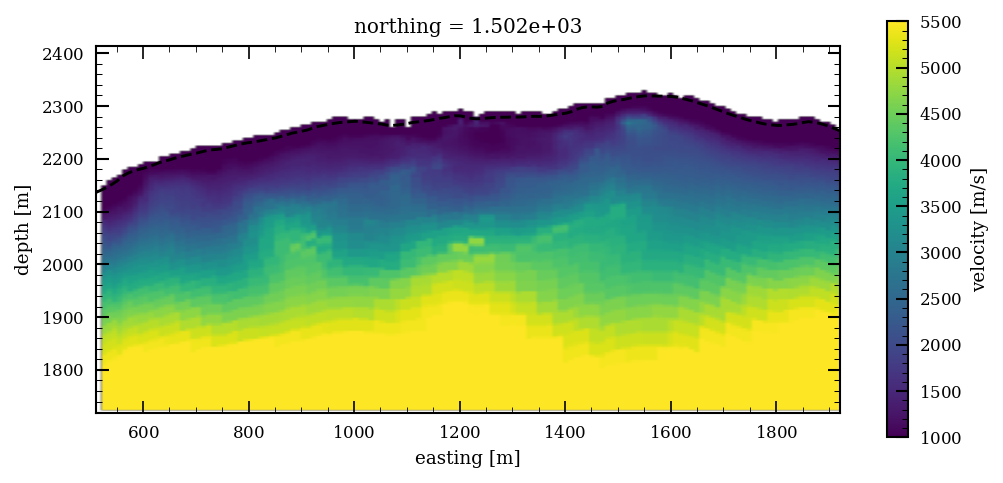

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

im_values = vp_model_shoulder.sel(northing=1500, method='nearest').T
im_values = xr.where(im_values < 500, np.nan, im_values) 

ax.imshow(
    im_values, origin='lower',
    extent=[x_min, x_max, z_min, z_max],
    cmap='viridis', vmin=1000, vmax=5500)
ax.set_aspect('equal')

topo_data_interp.sel(
    northing=1500, method='nearest').plot(ax=ax, color='k', linestyle='--')

ax.set_xlabel('easting [m]')
ax.set_ylabel('depth [m]')

plt.colorbar(ax.images[0], ax=ax, label='velocity [m/s]', shrink=0.6)

plt.show()

In [ ]:
import pykonal

class Pykonal_Forward:
    def __init__(self, x, y, z, seismic_grid):
        self.x_min, self.x_max, self.x_N = x.min(), x.max(), x.size
        self.y_min, self.y_max, self.y_N = y.min(), y.max(), y.size
        self.z_min, self.z_max, self.z_N = z.min(), z.max(), z.size      

        self.dx = (x_max - x_min) / x_N
        self.dy = (y_max - y_min) / y_N
        self.dz = (z_max - z_min) / z_N
                
        self.seismic_grid = seismic_grid
                
    def forward(self, source_coords):
        
        # receiver_vert = get_elevation(receiver_coords[..., :2], topo_ds_interp)
        # receiver_coords = np.hstack([receiver_coords, receiver_vert[:, None]])
        
        solver = pykonal.solver.PointSourceSolver()
        solver.velocity.min_coords     = self.x_min, self.y_min, self.z_min
        solver.velocity.node_intervals = self.dx, self.dy, self.dz
        solver.velocity.npts           = self.x_N, self.y_N, self.z_N
        solver.velocity.values         = self.seismic_grid.values
                
        solver.src_loc = source_coords
        solver.solve()
        
        return solver.traveltime

pyk_forward_shoulder = Pykonal_Forward(x, y, z, vp_model_shoulder)

In [ ]:
prior_samples_shoulder_uniform = torch.load('data/priors/prior_samples_shoulder_uniform.pt')
posterior_grid_shoulder = torch.load('data/priors/shoulder_posterior_grid.pt')

data_path = 'data/data_lookup'
os.makedirs(data_path, exist_ok=True)

In [ ]:
print(vp_model_shoulder.easting.values.min(), vp_model_shoulder.easting.values.max())
print(vp_model_shoulder.northing.values.min(), vp_model_shoulder.northing.values.max())
print(vp_model_shoulder.elevation.values.min(), vp_model_shoulder.elevation.values.max())

511.54000899987295 1921.540008999873
1131.6799999999348 1601.6799999999348
1718.2709155270331 2414.270915527033


In [ ]:
print(posterior_grid_shoulder[..., 0].min(), posterior_grid_shoulder[..., 0].max())
print(posterior_grid_shoulder[..., 1].min(), posterior_grid_shoulder[..., 1].max())
print(posterior_grid_shoulder[..., 2].min(), posterior_grid_shoulder[..., 2].max())

tensor(521.5400, dtype=torch.float64) tensor(1901.5400, dtype=torch.float64)
tensor(1141.6801, dtype=torch.float64) tensor(1581.6801, dtype=torch.float64)
tensor(1935.4762, dtype=torch.float64) tensor(2352.0122, dtype=torch.float64)


In [ ]:
shoulder_uniform_data_path = f'{data_path}/heterogeneous_shoulder_uniform.pt'
shoulder_shots_data_path = f'{data_path}/heterogeneous_shoulder_shots.pt'
shoulder_posterior_data_path = f'{data_path}/heterogeneous_shoulder_posterior.pt'

# Try to load existing data
if (os.path.exists(shoulder_uniform_data_path) and \
    os.path.exists(shoulder_shots_data_path) and \
    os.path.exists(shoulder_posterior_data_path)
    ):
    
    print("Loading pre-computed data...")
    shoulder_uniform_data = torch.load(shoulder_uniform_data_path)
    shoulder_shots_data = torch.load(shoulder_shots_data_path)
    shoulder_posterior_data = torch.load(shoulder_posterior_data_path)
    
else:
    print("Computing and saving data...")
    shoulder_uniform_data = torch.zeros(
        len(prior_samples_shoulder_uniform), len(design_space_shoulder))
    shoulder_shots_data = torch.zeros(
        len(events_shoulder), len(design_space_shoulder))
    shoulder_posterior_data = torch.zeros(
        len(posterior_grid_shoulder), len(design_space_shoulder))
    
    for i, receiver in tqdm(
        enumerate(design_space_shoulder),
        total=len(design_space_shoulder)):

        out = pyk_forward_shoulder.forward(
                source_coords=receiver[..., :3].double().numpy())     

        shoulder_uniform_data[:, i] = torch.tensor(out.resample(
            prior_samples_shoulder_uniform[..., :3].double().numpy()
            )).float()
        shoulder_shots_data[:, i] = torch.tensor(out.resample(
            events_shoulder[..., :3].double().numpy()
            )).float()
        shoulder_posterior_data[:, i] = torch.tensor(out.resample(
            posterior_grid_shoulder[..., :3].double().numpy()
            )).float()
        
    # Save computed data
    torch.save(shoulder_uniform_data, shoulder_uniform_data_path)
    torch.save(shoulder_shots_data, shoulder_shots_data_path)
    torch.save(shoulder_posterior_data, shoulder_posterior_data_path)


Computing and saving data...


  0%|          | 0/375 [00:00<?, ?it/s]

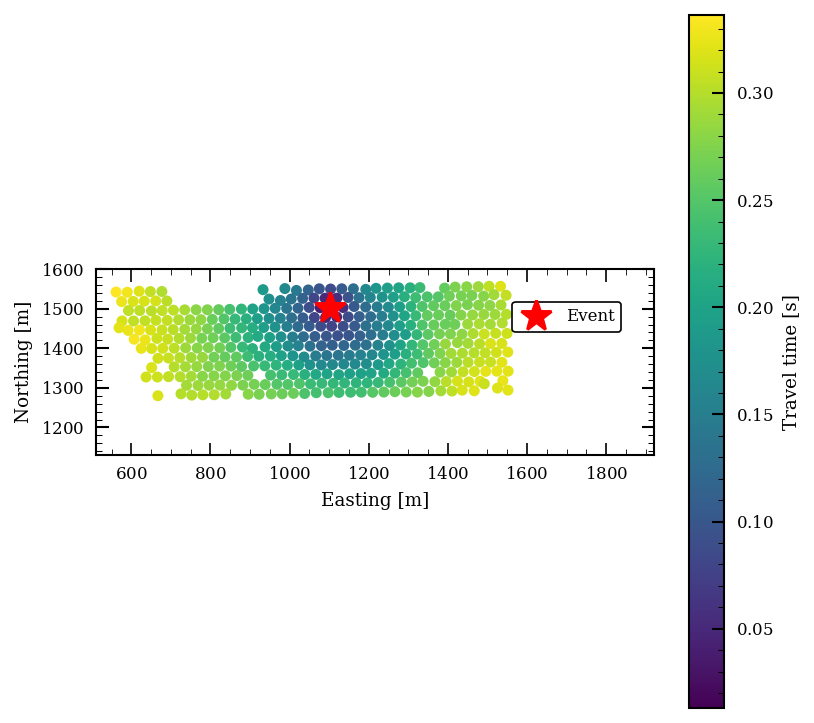

In [ ]:
# Define event index
event_idx = 10

fig, ax = plt.subplots(figsize=(6, 6))

# Get the specified event's data for all receivers
event_data = shoulder_shots_data[event_idx]

# Create scatter plot using receiver locations from design_space_shoulder
scatter = ax.scatter(
    design_space_shoulder[:, 0],  # easting
    design_space_shoulder[:, 1],  # northing
    c=event_data,       # color by travel time
    cmap='viridis',
    s=20               # marker size
)

# Plot the event location (specified event from prior_samples_full_uniform)
ax.plot(
    events_shoulder[event_idx, 0],
    events_shoulder[event_idx, 1],
    'r*', linewidth=0,
    markersize=15,
    label='Event'
)

# Add colorbar
plt.colorbar(scatter, label='Travel time [s]')

# Add contours of topography
# topo_data_interp.T.plot.contour(ax=ax, levels=20, colors='k', alpha=0.3)

ax.set_xlim(
    topo_data_interp.easting.values.min(),
    topo_data_interp.easting.values.max()
)
ax.set_ylim(
    topo_data_interp.northing.values.min(),
    topo_data_interp.northing.values.max()
    )

ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_aspect('equal')
ax.legend()

plt.show()

tensor([0.3606, 0.3622, 0.3620,  ..., 0.4111, 0.4104, 0.4092])
tensor([1102.1200, 1501.9301, 2266.6899,   10.0000])


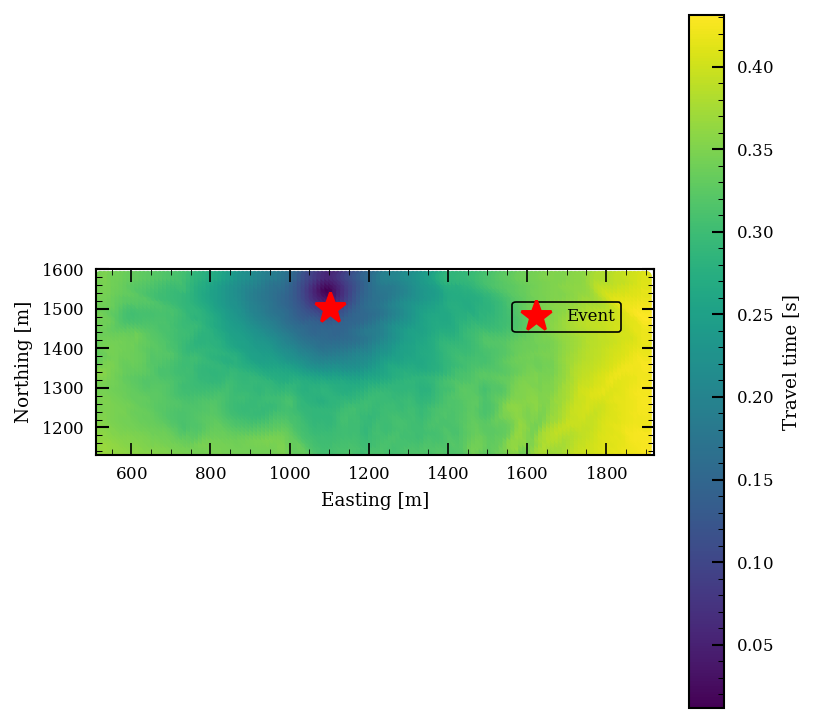

In [ ]:
# Define event index
event_idx = 10

fig, ax = plt.subplots(figsize=(6, 6))

# Get the specified event's data for all receivers
event_data = shoulder_posterior_data[..., event_idx]

print(event_data)
print(events_shoulder[event_idx])
# Create scatter plot using receiver locations from design_space_shoulder
scatter = ax.scatter(
    posterior_grid_shoulder[:, 0],  # easting
    posterior_grid_shoulder[:, 1],  # northing
    c=event_data,       # color by travel time
    cmap='viridis',
    s=20               # marker size
)

# Plot the event location (specified event from prior_samples_full_uniform)
ax.plot(
    events_shoulder[event_idx, 0],
    events_shoulder[event_idx, 1],
    'r*', linewidth=0,
    markersize=15,
    label='Event'
)

# Add colorbar
plt.colorbar(scatter, label='Travel time [s]')

# Add contours of topography
# topo_data_interp.T.plot.contour(ax=ax, levels=20, colors='k', alpha=0.3)

ax.set_xlim(
    topo_data_interp.easting.values.min(),
    topo_data_interp.easting.values.max()
)
ax.set_ylim(
    topo_data_interp.northing.values.min(),
    topo_data_interp.northing.values.max()
    )

ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_aspect('equal')
ax.legend()

plt.show()